# Pricing the whole book: pure premium, two ways

**The problem:** you need one final number per policy -- a full
pure-premium price -- not frequency and severity as two separate
outputs. insurabench gives you two routes to get there. This notebook
builds both on the same data and compares them, so you can see what each
one actually buys you.

- **Route A -- direct:** fit a single Tweedie (compound Poisson-Gamma)
  model straight on pure premium.
- **Route B -- composed:** fit a frequency model and a severity model
  separately, and multiply their predictions together.


## Setup

In [1]:
from insurabench.data.datasets import make_synthetic_two_table
from insurabench.data.policy_frame import PolicyFrame
from insurabench.model_selection import train_test_split_policy_frame

book = make_synthetic_two_table(n_policies=4000, renewals=True, seed=7)
pf = PolicyFrame.from_tables(
    book.policies, book.claims, book.policy_schema, book.claims_schema, verbose=False
)
train_pf, test_pf = train_test_split_policy_frame(pf, test_size=0.25, seed=7)


## Route A: one model, direct Tweedie

The simplest route: pick a `power` (1 < power < 2 for an insurance-like
compound Poisson-Gamma process) and fit one model straight on pure
premium.


In [2]:
from insurabench.models.glm import GLMPricingModel

direct_model = GLMPricingModel(family="tweedie", power=1.5).fit_policy_frame(train_pf, "pure_premium")
direct_pred = direct_model.predict_policy_frame(test_pf)

print(f"Direct Tweedie GLM -- test D²: {direct_model.score_policy_frame(test_pf):.3f}")


Direct Tweedie GLM -- test D²: 0.004


## Route B: compose a frequency model and a severity model

Fit each leg separately -- and, notably, each leg can be a different
model type. Here: a GBM for frequency (to pick up the threshold-style
effects notebook 02 found a GLM misses) and a GLM for severity.


In [3]:
from insurabench.models.gbm import GBMPricingModel
from insurabench.models.frequency_severity import FrequencySeverityModel

composed_model = FrequencySeverityModel(
    frequency_model=GBMPricingModel(family="poisson", iterations=200),
    severity_model=GLMPricingModel(family="gamma"),
).fit_policy_frame(train_pf)
composed_pred = composed_model.predict_policy_frame(test_pf)

print(f"Composed (GBM freq x GLM sev) -- test D²: {composed_model.score_policy_frame(test_pf, power=1.5):.3f}")


Composed (GBM freq x GLM sev) -- test D²: 0.007


## Comparing the two routes on the same footing

Both routes produce the same thing -- a predicted pure-premium rate per
policy -- so every curves/evaluation function works on either unchanged,
exactly as in notebook 02.


 Direct Tweedie  Gini: 0.091


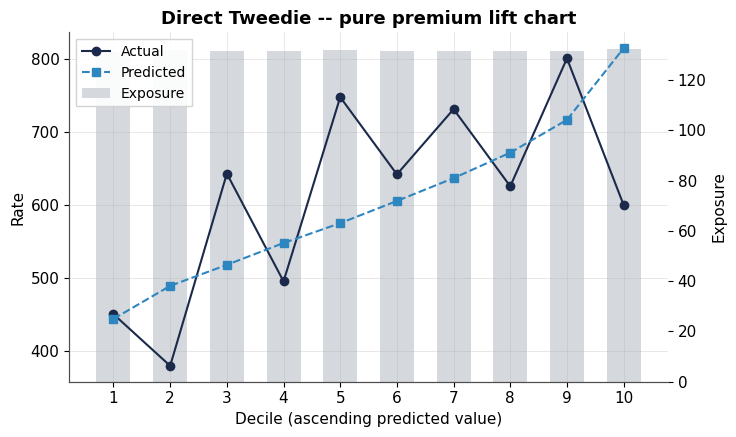

       Composed  Gini: 0.120


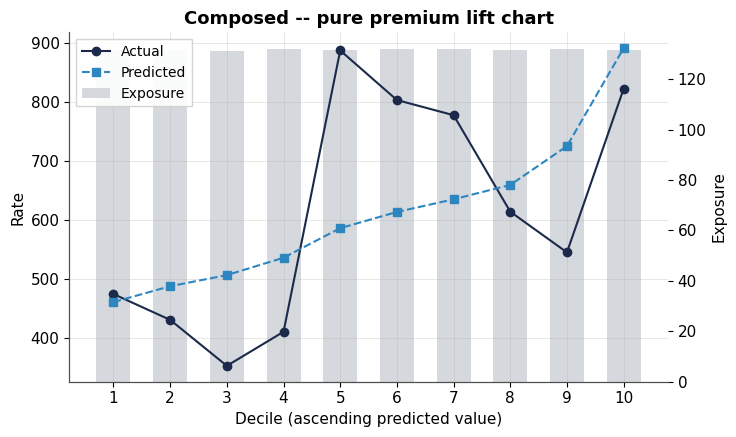

In [4]:
from insurabench.evaluation import gini_index, lift_chart
from insurabench.viz import plot_lift_chart

for name, y_pred in [("Direct Tweedie", direct_pred), ("Composed", composed_pred)]:
    print(f"{name:>15}  Gini: {gini_index(test_pf, 'pure_premium', y_pred):.3f}")
    chart = lift_chart(test_pf, "pure_premium", y_pred, n_deciles=10)
    plot_lift_chart(chart, title=f"{name} -- pure premium lift chart")


## Which route should you take?

Not a universal answer -- it depends on what you need:

- **Direct Tweedie** is one fit, one model to maintain, and is the
  simpler choice when frequency and severity don't need materially
  different treatment.
- **Composed** costs you two fits instead of one, but buys you two
  things the direct route can't give you: each leg can be a *different*
  model type (here, a GBM for frequency specifically because notebook 02
  showed it handles this book's threshold effects better, with a plain
  GLM for severity where there's no similar need), and you can inspect
  frequency drivers and severity drivers separately rather than only
  ever seeing their product.

Check the Gini numbers above on your own data before picking one --
don't assume either route wins in general.


## Next

**`04_from_model_to_deliverables.ipynb`** -- you've picked a model, now
what do you actually hand off to someone else?
